In [ ]:
from google.colab import files
uploded = files.upload()


Saving cleaned_stroke_dataset.csv to cleaned_stroke_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cleaned_stroke_dataset.csv")

In [ ]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


first 5 rows

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


Last 5 rows

In [ ]:
df.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,0,80.0,1,0,1,2,1,83.75,28.1,2,0
5106,0,81.0,0,0,1,3,1,125.20,40.0,2,0
5107,0,35.0,0,0,1,3,0,82.99,30.6,2,0
5108,1,51.0,0,0,1,2,0,166.29,25.6,1,0
5109,0,44.0,0,0,1,0,1,85.28,26.2,0,0


Shape of dataset

In [ ]:
df.shape

(5110, 11)

Dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 439.3 KB


Statistical summary

In [ ]:
df.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,0.414286,43.226614,0.097456,0.054012,0.656164,2.167710,0.508023,106.147677,28.862035,1.376908,0.048728
std,0.493044,22.612647,0.296607,0.226063,0.475034,1.090293,0.499985,45.283560,7.699562,1.071534,0.215320
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000
25%,0.000000,25.000000,0.000000,0.000000,0.000000,2.000000,0.000000,77.245000,23.800000,0.000000,0.000000
50%,0.000000,45.000000,0.000000,0.000000,1.000000,2.000000,1.000000,91.885000,28.100000,2.000000,0.000000
75%,1.000000,61.000000,0.000000,0.000000,1.000000,3.000000,1.000000,114.090000,32.800000,2.000000,0.000000
max,2.000000,82.000000,1.000000,1.000000,1.000000,4.000000,1.000000,271.740000,97.600000,3.000000,1.000000


Checking missing values

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


fill numerical missing values

In [ ]:
df.fillna(df.mean(), inplace=True)

fill categorial missing values

In [ ]:
df.fillna(df.mode().iloc[0], inplace=True)

To check duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)

to check target variable

In [ ]:
target = 'stroke'

to check stroke counts

In [ ]:
df[target].value_counts()

,count
stroke,
0,4861
1,249


Plot stroke distribution
- shows stroke vs non stroke patients
- Helps detect class imbalance

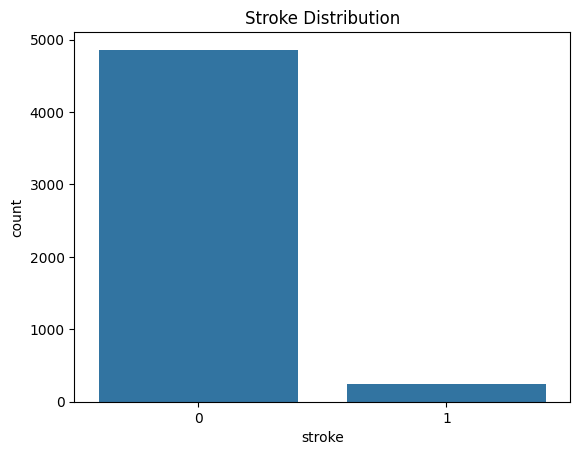

In [ ]:
sns.countplot(x='stroke', data=df)

plt.title("Stroke Distribution")

plt.show()

To check correlation matrix
- finds relationship btw numeric columns

In [ ]:
df.corr(numeric_only=True)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,-0.028202,0.020994,0.085447,-0.031005,0.056422,-0.006738,0.055180,-0.026952,-0.062581,0.008929
age,-0.028202,1.000000,0.276398,0.263796,0.679125,-0.361642,0.014180,0.238171,0.324296,0.265199,0.245257
hypertension,0.020994,0.276398,1.000000,0.108306,0.164243,-0.051761,-0.007913,0.174474,0.158293,0.111038,0.127904
heart_disease,0.085447,0.263796,0.108306,1.000000,0.114644,-0.028023,0.003092,0.161857,0.036916,0.048460,0.134914
ever_married,-0.031005,0.679125,0.164243,0.114644,1.000000,-0.352722,0.006261,0.155068,0.334911,0.259647,0.108340
work_type,0.056422,-0.361642,-0.051761,-0.028023,-0.352722,1.000000,-0.007316,-0.050513,-0.299172,-0.305927,-0.032316
Residence_type,-0.006738,0.014180,-0.007913,0.003092,0.006261,-0.007316,1.000000,-0.004946,-0.000277,0.008237,0.015458
avg_glucose_level,0.055180,0.238171,0.174474,0.161857,0.155068,-0.050513,-0.004946,1.000000,0.166876,0.063437,0.131945
bmi,-0.026952,0.324296,0.158293,0.036916,0.334911,-0.299172,-0.000277,0.166876,1.000000,0.218968,0.036110
smoking_status,-0.062581,0.265199,0.111038,0.048460,0.259647,-0.305927,0.008237,0.063437,0.218968,1.000000,0.028123


Correlation Heatmap

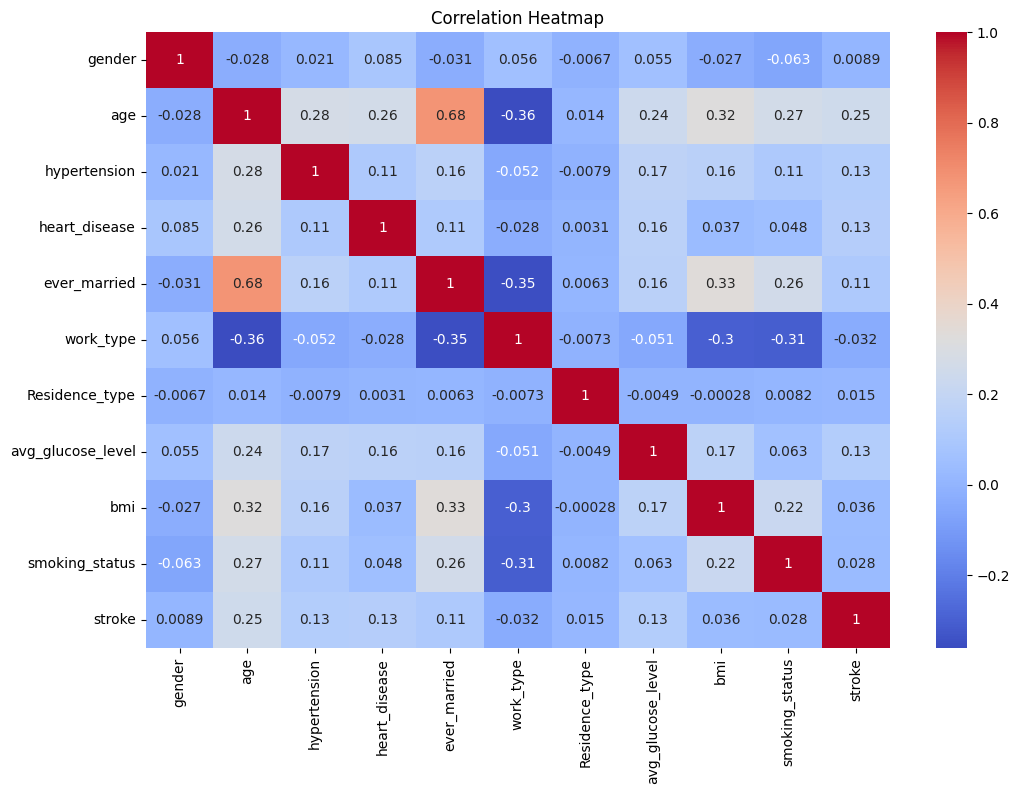

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Age distribution histogram

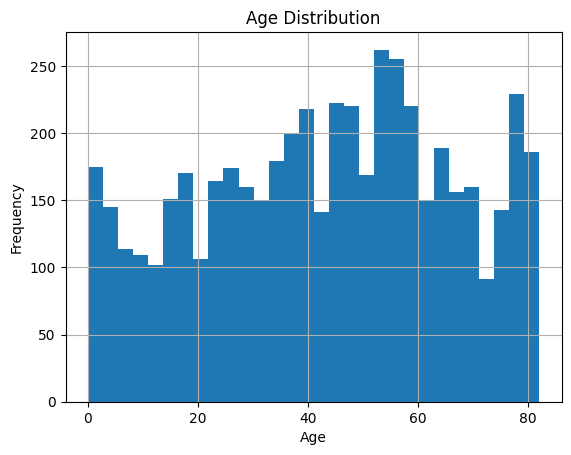

In [ ]:
df['age'].hist(bins=30)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

BMI distribution Histogram

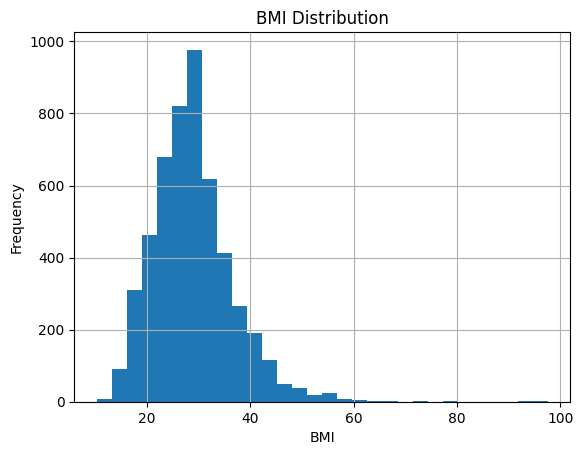

In [ ]:
df['bmi'].hist(bins=30)

plt.title("BMI Distribution")

plt.xlabel("BMI")

plt.ylabel("Frequency")

plt.show()

Glucose level distribution

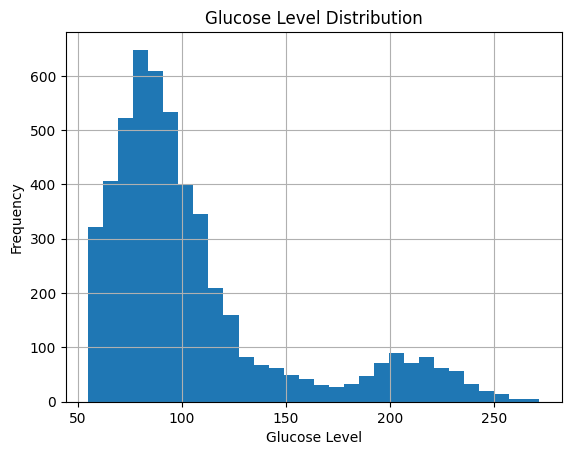

In [ ]:
df['avg_glucose_level'].hist(bins=30)

plt.title("Glucose Level Distribution")

plt.xlabel("Glucose Level")

plt.ylabel("Frequency")

plt.show()

Age vs stroke

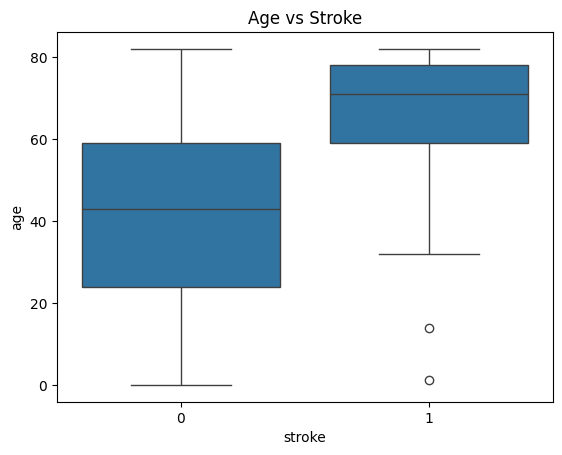

In [ ]:
sns.boxplot(x='stroke',
            y='age',
            data=df)

plt.title("Age vs Stroke")

plt.show()

BMI vs Stroke

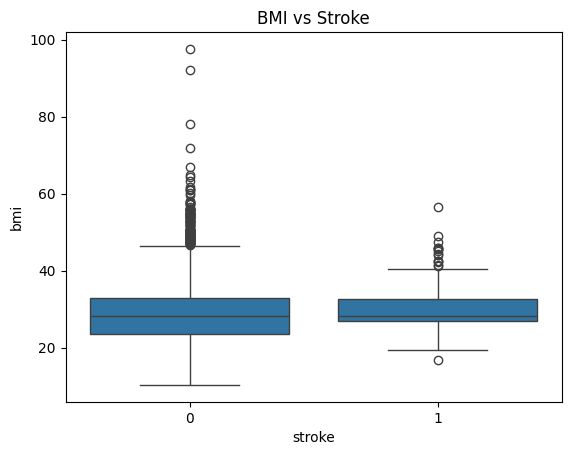

In [ ]:
sns.boxplot(x='stroke',
            y='bmi',
            data=df)

plt.title("BMI vs Stroke")

plt.show()

Glucose vs Stroke
- check if high glucose affect stroke

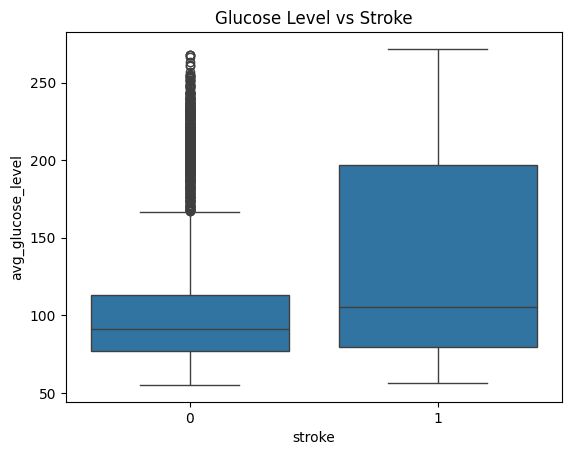

In [ ]:
sns.boxplot(x='stroke',
            y='avg_glucose_level',
            data=df)

plt.title("Glucose Level vs Stroke")

plt.show()

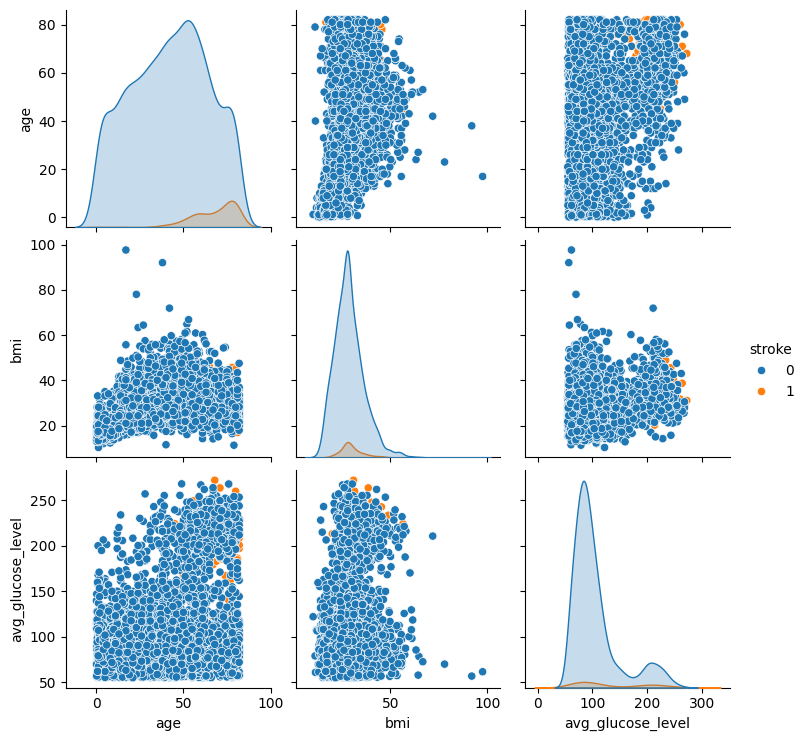

In [ ]:
sns.pairplot(df[['age',
                 'bmi',
                 'avg_glucose_level',
                 'stroke']],
             hue='stroke')

plt.show()

Study age and glucose relationship

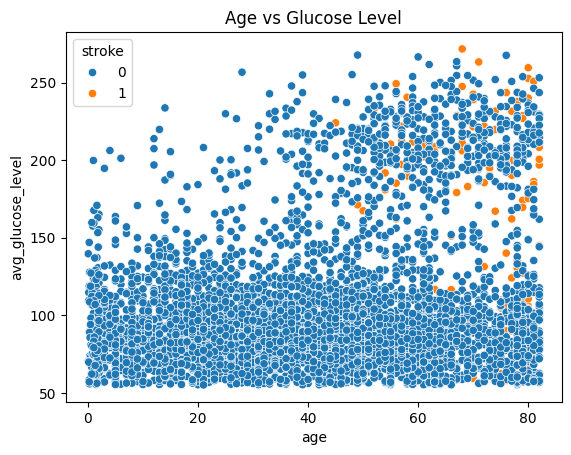

In [ ]:
sns.scatterplot(x='age',
                y='avg_glucose_level',
                hue='stroke',
                data=df)

plt.title("Age vs Glucose Level")

plt.show()

To detect abnormal values

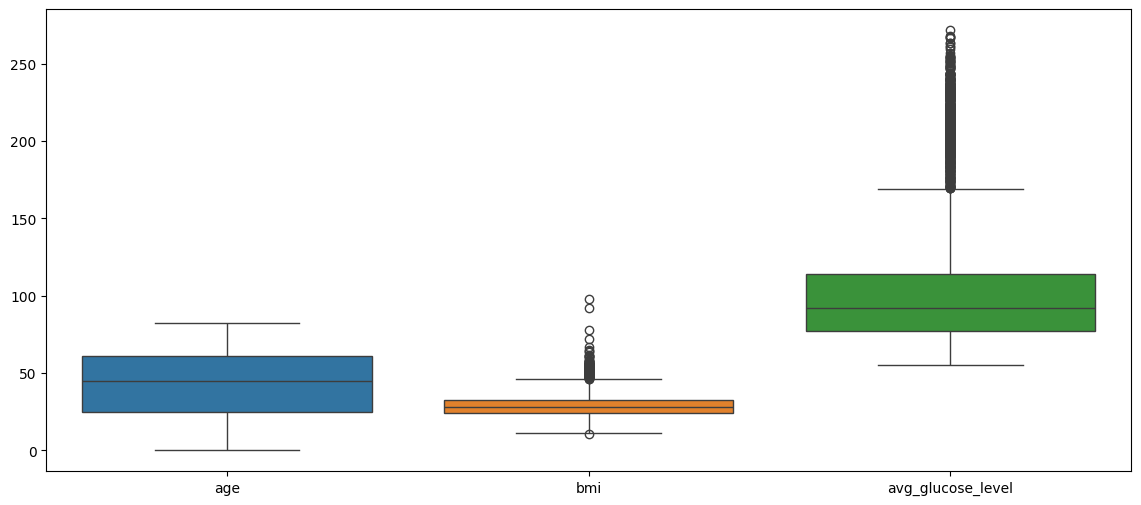

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df[['age',
                     'bmi',
                     'avg_glucose_level']])

plt.show()

Feature Correlation with stroke
- to identify most important features

In [ ]:
corr = df.corr(numeric_only=True)['stroke'].sort_values(ascending=False)

print(corr)

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
work_type           -0.032316
Name: stroke, dtype: float64


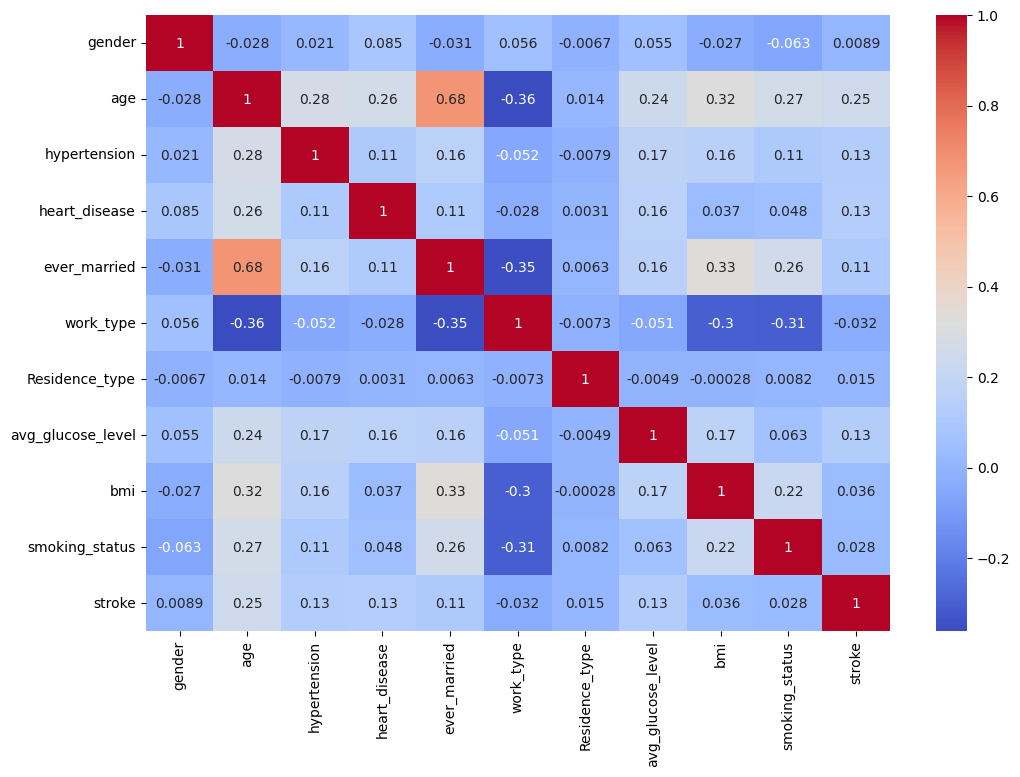

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.savefig("heatmap.png")

plt.show()

Insight
- Most stroke patients belong to older age groups

- High glucose levels are linked with higher stroke risk

- Patients with hypertension show increased stroke chances

- Heart disease patients are more prone to stroke

- BMI contains several outliers in the dataset

- Stroke cases are fewer compared to non-stroke cases

- Some medical features are positively correlated with stroke

- Data visualization helped identify important health patterns
